In [ ]:
import os ,sys, glob, json

import numpy as np
import scipy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import onnxruntime as ort
from tqdm import tqdm

glo_path = os.getcwd().split("o2-tpc-pid")[0]
sys.path.append(glo_path + "/o2-tpc-pid/framework")

import mplhep as hep
plt.style.use(hep.styles.ALICE)
for key in mpl.rcParams.keys():
    if key.startswith('legend.'):
        mpl.rcParams[key] = mpl.rcParamsDefault[key]

from neural_network_class.NeuralNetworkClasses.extract_from_root import *

In [3]:
def network(data, ort_session, input_name=None):
    x = np.asarray(data, dtype=np.float32)

    if input_name is None:
        input_name = ort_session.get_inputs()[0].name

    outputs = ort_session.run(None, {input_name: x})
    return outputs[0] if len(outputs) == 1 else outputs


def get_networks(path):
    return sorted(glob.glob(path, recursive=True))


def create_network_sessions(networks, threads=32, use_gpu=True):
    sessions = []

    available = ort.get_available_providers()
    providers = (
        ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if use_gpu and "CUDAExecutionProvider" in available
        else ["CPUExecutionProvider"]
    )

    opts = ort.SessionOptions()
    opts.intra_op_num_threads = threads
    opts.inter_op_num_threads = threads
    opts.execution_mode = ort.ExecutionMode.ORT_PARALLEL

    for model_path in networks:
        session = ort.InferenceSession(
            model_path,
            sess_options=opts,
            providers=providers,
        )
        sessions.append(session)

    return sessions


def get_network_predictions(data, sessions):
    predictions = []

    for session in tqdm(sessions):
        pred = network(data, session)
        predictions.append(pred)

    return np.array(predictions)

In [4]:
cf = "/scratch/csonnabe/o2-tpc-pid/output/LHC24/ar/apass2/LHC24ar_apass2_TPCSignal_paperstudy_ensemble_0_HadronicRate_DeltaPhi/20260623/configuration.json"
with open(cf, 'r') as config_file:
    CONFIG = json.load(config_file)
sys.path.append(CONFIG['settings']['framework'] + "/framework")
from base import *
from math_functions import *
from neural_network_class.NeuralNetworkClasses.extract_from_root import *
nnconfig = import_from_path(CONFIG["trainNeuralNetOptions"]["configuration"])

########### Import the Neural Network class ###########

# Follow old-script behavior: read HadronicRate from config and cast to bool
HadronicRateBool = "fHadronicRate" in CONFIG['createTrainingDatasetOptions']['labels_x']
PhiBool = "fPhi" in CONFIG['createTrainingDatasetOptions']['labels_x']

## Loading data and models

particles                   = particle_info["particles"]
particle_labels             = particle_info["particle_labels"]
masses                      = particle_info["masses"]
charges                     = particle_info["charges"]
dict_particles_masses       = dict(zip(particles, masses))

### Neural Network

training_folder = CONFIG["output"]["general"]["training"] #general output dir for training
qa_dir          = CONFIG["output"]["trainNeuralNet"]["QApath"] #output directory for QA plots
data_path       = CONFIG["output"]["createTrainingDataset"]["training_data"]

LABELS_X = CONFIG["createTrainingDatasetOptions"]["labels_x"]
LABELS_Y = CONFIG["createTrainingDatasetOptions"]["labels_y"]

### General
fontsize_axislabels = 30
momentum = np.logspace(-2,3,1000)
cload = load_tree()
data = cload.load(use_vars=None, path=data_path, load_latest=True, verbose=True)
labels = np.array(data[0])
fit_data = data[1]
del data

reorder_index = []
for lab in [*LABELS_Y, *LABELS_X]:
    reorder_index.append(np.where(labels==lab)[0][0])
reorder_index = np.array(reorder_index)
fit_data = fit_data[:,reorder_index]
labels = labels[reorder_index]
mask_X = []
mask_y = []
for l in labels:
    mask_X.append(l in LABELS_X)
    mask_y.append(l in LABELS_Y)

[DEBUG] Reading ROOT file
[DEBUG] Top-level keys: ['data_tree;1']
[DEBUG] Key: data_tree;1, type: <class 'uproot.models.TTree.Model_TTree_v20'>
[DEBUG] -> accepted as tabular object, entries=9998199
data_tree;1 (1/1)
Branch Names: ['fTPCSignal', 'fInvDeDxExpTPC', 'fTPCInnerParam', 'fTgl', 'fSigned1Pt', 'fMass', 'fNormMultTPC', 'fNormNClustersTPC', 'fFt0Occ', 'fHadronicRate', 'fPhi', 'fPidIndex', 'fRunNumber']
Shape of stacked values: (9998199, 13) 



In [5]:
output = get_networks("/scratch/csonnabe/o2-tpc-pid/output/LHC24/ar/apass2/LHC24ar_apass2_TPCSignal_paperstudy_ensemble_*_HadronicRate_DeltaPhi/**/network_full/net_onnx_full.onnx")
net_sessions = create_network_sessions(output)

2026-06-24 10:04:31.823976520 [E:onnxruntime:Default, provider_bridge_ort.cc:1992 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1637 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-06-24 10:04:31.824019823 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:965 CreateExecutionProviderInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.
2026-06-24 10:04:31.860686879 [E:onnxruntime:Default, provider_bridge_ort.cc:1992 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_

In [6]:
net_output = get_network_predictions(fit_data[:,mask_X], net_sessions)

100%|██████████| 100/100 [02:04<00:00,  1.25s/it]


In [7]:
mean_mean_prediction = np.mean(net_output[:,:,0], axis=0)
sigma_mean_prediction = np.std(net_output[:,:,0], axis=0)
mean_sigma_prediction = np.mean(net_output[:,:,1], axis=0)
sigma_sigma_prediction = np.std(net_output[:,:,1], axis=0)

In [ ]:
np.save("./data//net_output.npy", net_output)
np.save("./data//mean_mean_prediction.npy", mean_mean_prediction)
np.save("./data//sigma_mean_prediction.npy", sigma_mean_prediction)
np.save("./data//mean_sigma_prediction.npy", mean_sigma_prediction)
np.save("./data//sigma_sigma_prediction.npy", sigma_sigma_prediction)

In [ ]:
net_output = np.load("./data/net_output.npy")
mean_mean_prediction = np.load("./data/mean_mean_prediction.npy")
sigma_mean_prediction = np.load("./data/sigma_mean_prediction.npy")
mean_sigma_prediction = np.load("./data/mean_sigma_prediction.npy")
sigma_sigma_prediction = np.load("./data/sigma_sigma_prediction.npy")

In [10]:
default_ranges = {
    "fTPCInnerParam": [-1., np.log10(20.)],
    "fTgl": [-1., 1.],
    "fNormNClustersTPC": [0.5, 152.5],
    "fNormMultTPC": [0., 3.],
    "fFt0Occ": [-0.3, 5.],
    "fHadronicRate": [-1., 0.1]
}
default_scaling_x = {
    "fTPCInnerParam": True, # log_x
    "fTgl": False,
    "fNormNClustersTPC": False,
    "fNormMultTPC": False,
    "fFt0Occ": False,
    "fHadronicRate": True
}

In [13]:
from scipy.ndimage import gaussian_filter
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def plot_prediction_difference_matrix(
    fit_data,
    mask_X,
    LABELS_X,
    numerator_prediction,
    denominator_prediction,
    default_ranges,
    default_scaling_x,
    quantity_label="Percent difference [%]",
    output_name="prediction_difference_matrix",
    nx=400,
    ny=400,
    smooth=2.0,
    fontsize_axislabels=14,
):
    """
    Matrix-style upper/lower triangle plot.

    z = 100 * (numerator_prediction / denominator_prediction)
    """

    lbl_idx = np.array(LABELS_X)
    axis_data = fit_data[:, mask_X]

    numerator_prediction = np.asarray(numerator_prediction).ravel()
    denominator_prediction = np.asarray(denominator_prediction).ravel()

    z = 100.0 * (numerator_prediction / denominator_prediction)

    pretty_labels = {
        "fTPCInnerParam": r"$p$ [GeV/$c$]",
        "fTgl": r"$\tan(\lambda)$",
        "fNormNClustersTPC": r"NCl$_{TPC}$",
        "fNormMultTPC": r"Norm. TPC multiplicity",
        "fFt0Occ": r"Norm. FT0 occupancy",
        "fHadronicRate": r"Hadronic rate [50 kHz]",
        "fPhi": r"$\varphi - k\pi/9$",
    }

    def transform_axis(v, label):
        v = np.asarray(v, dtype=float)
        if label == "fNormNClustersTPC":
            return 152.0 / (v**2)
        return v

    def to_scaled(v, label):
        v = np.asarray(v, dtype=float)
        if default_scaling_x[label]:
            return np.log10(v)
        return v

    def from_scaled(v, label):
        v = np.asarray(v, dtype=float)
        if default_scaling_x[label]:
            return 10**v
        return v

    def fast_binned_surface(x, y, z, xr, yr):
        xedges = np.linspace(xr[0], xr[1], nx + 1)
        yedges = np.linspace(yr[0], yr[1], ny + 1)

        sum_grid, _, _ = np.histogram2d(
            x, y,
            bins=[xedges, yedges],
            weights=z,
        )

        count_grid, _, _ = np.histogram2d(
            x, y,
            bins=[xedges, yedges],
        )

        sum_smooth = gaussian_filter(sum_grid, sigma=smooth)
        count_smooth = gaussian_filter(count_grid, sigma=smooth)

        mean_grid = np.divide(
            sum_smooth,
            count_smooth,
            out=np.full_like(sum_smooth, np.nan, dtype=float),
            where=count_smooth > 0,
        )

        return mean_grid.T, xedges, yedges

    plot_labels = [l for l in LABELS_X if l in default_ranges]
    n = len(plot_labels)

    panels = {}

    for ix, l1 in enumerate(plot_labels):
        for iy, l2 in enumerate(plot_labels):
            if iy <= ix:
                continue

            x_raw = axis_data[:, lbl_idx == l1].ravel()
            y_raw = axis_data[:, lbl_idx == l2].ravel()

            x_raw = transform_axis(x_raw, l1)
            y_raw = transform_axis(y_raw, l2)

            mask = (
                np.isfinite(x_raw) &
                np.isfinite(y_raw) &
                np.isfinite(z) &
                np.isfinite(numerator_prediction) &
                np.isfinite(denominator_prediction) &
                (denominator_prediction != 0)
            )

            if default_scaling_x[l1]:
                mask &= x_raw > 0
            if default_scaling_x[l2]:
                mask &= y_raw > 0

            x_raw = x_raw[mask]
            y_raw = y_raw[mask]
            z_plot = z[mask]

            sx = to_scaled(x_raw, l1)
            sy = to_scaled(y_raw, l2)

            sx_min, sx_max = default_ranges[l1]
            sy_min, sy_max = default_ranges[l2]

            keep = (
                (sx >= sx_min) & (sx <= sx_max) &
                (sy >= sy_min) & (sy <= sy_max)
            )

            sx = sx[keep]
            sy = sy[keep]
            z_plot = z_plot[keep]

            if len(z_plot) < 20:
                continue

            zz, xedges_scaled, yedges_scaled = fast_binned_surface(
                sx,
                sy,
                z_plot,
                xr=[sx_min, sx_max],
                yr=[sy_min, sy_max],
            )

            panels[(iy, ix)] = {
                "l1": l1,
                "l2": l2,
                "zz": zz,
                "xedges": from_scaled(xedges_scaled, l1),
                "yedges": from_scaled(yedges_scaled, l2),
            }

    norm = TwoSlopeNorm(vmin=0.2, vcenter=2.1, vmax=4.0)
    #norm = LogNorm(vmin=0.2, vmax=3.0)

    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": fontsize_axislabels,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })

    fig, axes = plt.subplots(
        n - 1,
        n - 1,
        figsize=(2.8 * (n - 1), 2.8 * (n - 1)),
        squeeze=False,
    )

    # Hide all axes first, so unused lower-triangle slots have no frames/ticks
    for ax in axes.ravel():
        ax.axis("off")

    mappable = None
    for iy, l2 in enumerate(plot_labels):
        for ix, l1 in enumerate(plot_labels):

            if iy <= ix:
                continue

            # Compact mapping: original row iy=1 becomes subplot row 0
            ax = axes[iy - 1, ix]

            panel = panels.get((iy, ix))

            if panel is None:
                continue

            # Re-enable only axes that actually get data
            ax.axis("on")

            mappable = ax.pcolormesh(
                panel["xedges"],
                panel["yedges"],
                panel["zz"],
                shading="auto",
                cmap=plt.cm.plasma,
                norm=norm,
            )

            if default_scaling_x[l1]:
                ax.set_xscale("log")
            if default_scaling_x[l2]:
                ax.set_yscale("log")

            ax.set_xlim(from_scaled(default_ranges[l1], l1))
            ax.set_ylim(from_scaled(default_ranges[l2], l2))

            ax.grid(alpha=0.25, linewidth=0.5)

            if iy != n - 1:
                ax.set_xticklabels([])
            if ix != 0:
                ax.set_yticklabels([])

    fig.subplots_adjust(
        left=0.13,
        right=0.86,
        bottom=0.13,
        top=0.97,
        wspace=0.08,
        hspace=0.08,
    )

    # Larger and closer colorbar
    fig.canvas.draw()

    # Vertical extent of the compact subplot grid
    top_bbox = axes[0, 0].get_position()
    bottom_bbox = axes[-1, 0].get_position()
    right_bbox = axes[0, -1].get_position()

    grid_bottom = bottom_bbox.y0
    grid_top = top_bbox.y1
    grid_height = grid_top - grid_bottom

    # Colorbar: full height of all subplot rows, close to the grid
    cbar_pad = 0.008
    cbar_width = 0.030

    cbar_ax = fig.add_axes([
        right_bbox.x1 + cbar_pad,
        grid_bottom,
        cbar_width,
        grid_height,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax)

    cbar.set_label(
        quantity_label,
        fontsize=fontsize_axislabels + 8,
        labelpad=16,
    )
    cbar.ax.tick_params(labelsize=fontsize_axislabels + 4)

    # Centered matrix-level axis labels
    fig.canvas.draw()

    for ix, l1 in enumerate(plot_labels[:-1]):
        bbox = axes[-1, ix].get_position()
        x_center = 0.5 * (bbox.x0 + bbox.x1)

        fig.text(
            x_center,
            bbox.y0 - 0.045,
            pretty_labels.get(l1, l1),
            ha="center",
            va="top",
            fontsize=fontsize_axislabels,
        )

    for iy_compact, l2 in enumerate(plot_labels[1:]):
        bbox = axes[iy_compact, 0].get_position()
        y_center = 0.5 * (bbox.y0 + bbox.y1)

        fig.text(
            bbox.x0 - 0.055,
            y_center,
            pretty_labels.get(l2, l2),
            ha="right",
            va="center",
            rotation=90,
            fontsize=fontsize_axislabels,
        )

    plt.savefig(f"{output_name}.pdf", bbox_inches="tight")
    #plt.show()
    plt.close()

In [ ]:
plot_prediction_difference_matrix(
    fit_data,
    mask_X,
    LABELS_X,
    numerator_prediction=sigma_sigma_prediction,
    denominator_prediction=mean_sigma_prediction,
    default_ranges=default_ranges,
    default_scaling_x=default_scaling_x,
    nx=100,
    ny=100,
    quantity_label=r"$100 \times (\sigma_{\sigma} / \mu_{\sigma})$ [%]",
    output_name="plots/sigma_sigma_over_mean_sigma_percent_difference",
)

plot_prediction_difference_matrix(
    fit_data,
    mask_X,
    LABELS_X,
    numerator_prediction=sigma_mean_prediction,
    denominator_prediction=mean_mean_prediction,
    default_ranges=default_ranges,
    default_scaling_x=default_scaling_x,
    nx=100,
    ny=100,
    quantity_label=r"$100 \times (\sigma_{\mu} / \mu_{\mu})$ [%]",
    output_name="plots/sigma_mean_over_mean_mean_percent_difference",
)

In [61]:
np.max(100.0 * (sigma_sigma_prediction / mean_sigma_prediction)), np.min(100.0 * (sigma_sigma_prediction / mean_sigma_prediction))

(np.float32(3.7550058), np.float32(0.21589626))

In [62]:
np.max(100.0 * (sigma_mean_prediction / mean_mean_prediction)), np.min(100.0 * (sigma_mean_prediction / mean_mean_prediction))

(np.float32(4.082679), np.float32(0.20236072))

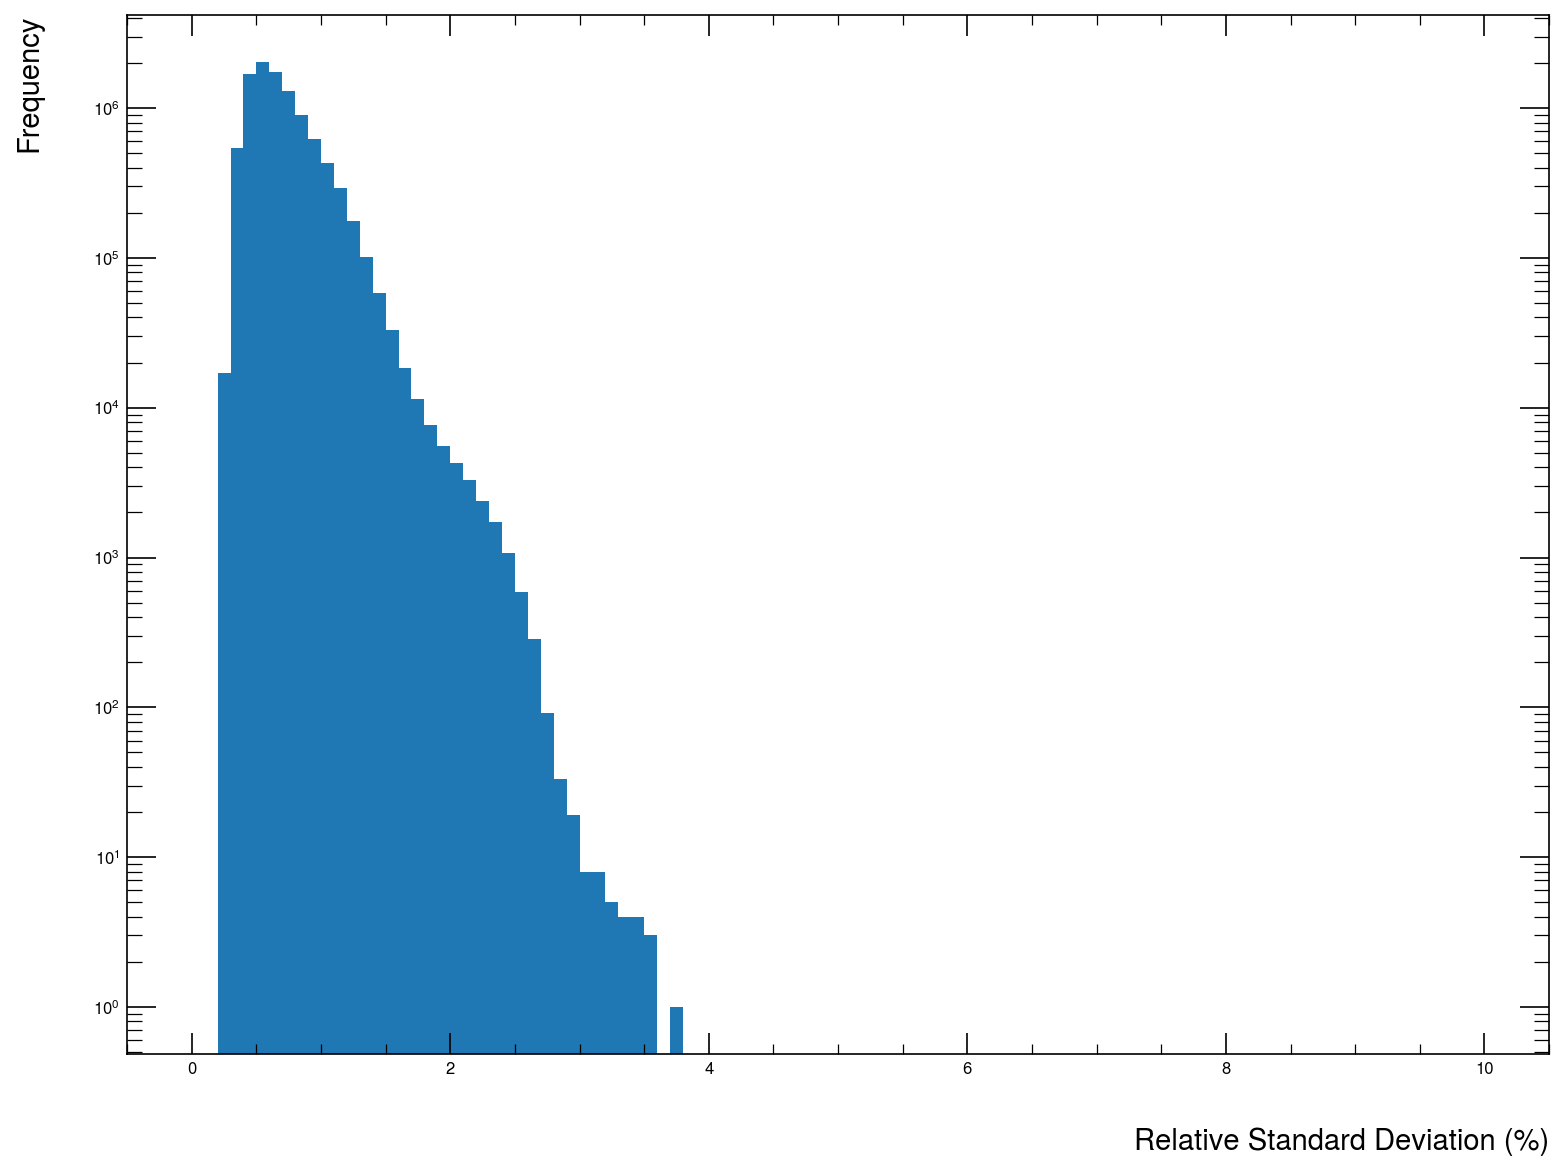

In [64]:
plt.hist(100.0 * (sigma_sigma_prediction / mean_sigma_prediction), bins=100, range=(0, 10))
plt.xlabel('Relative Standard Deviation (%)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

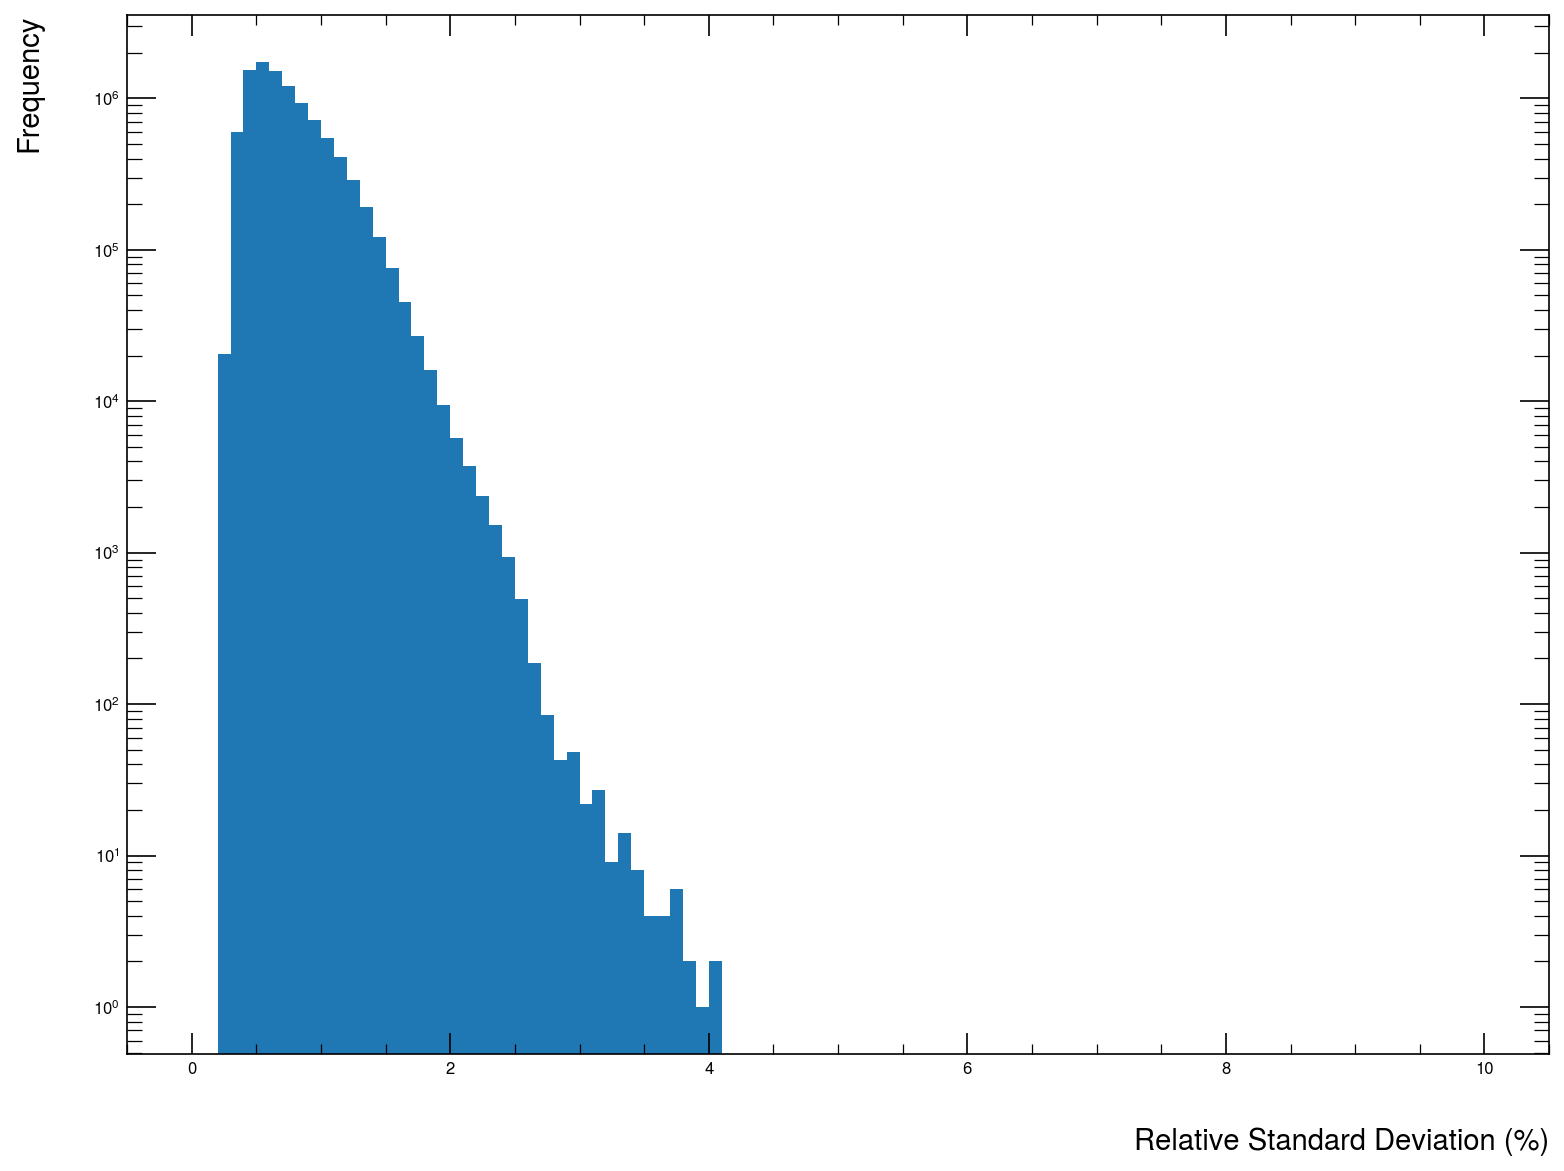

In [65]:
plt.hist(100.0 * (sigma_mean_prediction / mean_mean_prediction), bins=100, range=(0, 10))
plt.xlabel('Relative Standard Deviation (%)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()